
# Banknote Authentication with SVM (Hinge Loss)

This notebook implements a Support Vector Machine (SVM) from scratch using:
- Hinge Loss (non-differentiable loss function)
- Two optimization strategies:
  - Gradient Descent
  - Subgradient Descent

We'll use the Banknote Authentication dataset.


In [1]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("data_banknote_authentication.csv", header=None)
df.columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

# Features and labels
X = df.drop('class', axis=1).values
y = df['class'].values

# Convert labels from {0, 1} to {-1, 1} for hinge loss
y = np.where(y == 0, -1, 1)

# Split the dataset
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [2]:

def hinge_loss(w, b, X, y):
    margins = 1 - y * (np.dot(X, w) + b)
    loss = np.mean(np.maximum(0, margins))
    return loss
def squared_hinge_loss(w, b, X, y):
    margins = 1 - y * (np.dot(X, w) + b)
    loss = np.mean(np.square(np.maximum(0, margins)))
    return loss
def log_loss(w, b, X, y):
    z = np.dot(X, w) + b
    probs = 1 / (1 + np.exp(-z))
    loss = -np.mean(y * np.log(probs + 1e-15) + (1 - y) * np.log(1 - probs + 1e-15))
    return loss

In [3]:
def train_svm_gd(X, y, lr=0.01, epochs=100, reg=0.01):
    n, d = X.shape
    w_gd = np.zeros(d)
    b_gd = 0
    gd_train_losses, gd_val_losses = [], []
    gd_train_accuracies, gd_val_accuracies = [], []
    
    for epoch in range(epochs):
        margins = 1 - y * (np.dot(X, w_gd) + b_gd)
        indicator = margins > 0

        dw = -np.mean((indicator * y)[:, np.newaxis] * X, axis=0) + reg * w_gd
        db = -np.mean(indicator * y)
        
        w_gd -= lr * dw
        b_gd -= lr * db
        
        train_loss = hinge_loss(w_gd, b_gd, X, y)
        val_loss = hinge_loss(w_gd, b_gd, X_val, y_val)
        y_pred_train = np.sign(np.dot(X, w_gd) + b_gd)
        y_pred_val = np.sign(np.dot(X_val, w_gd) + b_gd)
        
        gd_train_losses.append(train_loss)
        gd_val_losses.append(val_loss)
        gd_train_accuracies.append(accuracy_score(y, y_pred_train))
        gd_val_accuracies.append(accuracy_score(y_val, y_pred_val))
    
    return w_gd, b_gd, gd_train_losses, gd_val_losses, gd_train_accuracies, gd_val_accuracies


In [4]:
def train_svm_subgrad(X, y, lr=0.01, epochs=100, reg=0.01):
    n, d = X.shape
    w_sg = np.zeros(d)
    b_sg = 0
    sg_train_losses, sg_val_losses = [], []
    sg_train_accuracies, sg_val_accuracies = [], []
    
    for epoch in range(epochs):
        # Pick a random training sample (stochastic update)
        i = np.random.randint(n)
        x_i = X[i]
        y_i = y[i]
        
        if y_i * (np.dot(x_i, w_sg) + b_sg) < 1:
            dw = -y_i * x_i + reg * w_sg
            db = -y_i
        else:
            dw = reg * w_sg
            db = 0

        # Update weights
        w_sg -= lr * dw
        b_sg -= lr * db

        # Track loss and accuracy
        train_loss = hinge_loss(w_sg, b_sg, X, y)
        val_loss = hinge_loss(w_sg, b_sg, X_val, y_val)
        y_pred_train = np.sign(np.dot(X, w_sg) + b_sg)
        y_pred_val = np.sign(np.dot(X_val, w_sg) + b_sg)
        
        sg_train_losses.append(train_loss)
        sg_val_losses.append(val_loss)
        sg_train_accuracies.append(accuracy_score(y, y_pred_train))
        sg_val_accuracies.append(accuracy_score(y_val, y_pred_val))

    return w_sg, b_sg, sg_train_losses, sg_val_losses, sg_train_accuracies, sg_val_accuracies


In [5]:

epochs = 100

# Gradient Descent
w_gd, b_gd, loss_gd_train, loss_gd_val, acc_gd_train, acc_gd_val = train_svm_gd(X_train, y_train, epochs=epochs)

# Subgradient Descent
w_sg, b_sg, loss_sg_train, loss_sg_val, acc_sg_train, acc_sg_val = train_svm_subgrad(X_train, y_train, epochs=epochs)


In [6]:

loss_gd_train


[0.9922428286933818,
 0.9844864188435722,
 0.9767307703744257,
 0.9689758832098037,
 0.9612217572735761,
 0.95346839248962,
 0.9457157887818199,
 0.937963946074069,
 0.9302128642902662,
 0.9224625433543199,
 0.9147129831901449,
 0.9069641837216643,
 0.8992161448728084,
 0.8914688665675152,
 0.8837223487297305,
 0.8759765912834074,
 0.8682315941525068,
 0.8604873572609972,
 0.8527438805328545,
 0.8450011638920626,
 0.8372592072626125,
 0.8295180105685034,
 0.8217775737337415,
 0.814037896682341,
 0.8062989793383233,
 0.798560821625718,
 0.7908234234685618,
 0.7830867847908993,
 0.7753509055167823,
 0.7676157855702705,
 0.7598814248754314,
 0.7521478233563396,
 0.7444149809370775,
 0.7366828975417352,
 0.728996364227035,
 0.7214714044408164,
 0.7141402280349529,
 0.7070013145173725,
 0.6999911586044169,
 0.6930345983430986,
 0.6861901165359732,
 0.6794366219459852,
 0.6727112872735314,
 0.6660047174338912,
 0.6593848475110233,
 0.652880072214188,
 0.6466759131785904,
 0.64072227737312,
 

In [7]:
# Print final training and validation accuracy
print("Gradient Descent - Final Training Accuracy:", acc_gd_train[-1])
print("Gradient Descent - Final Validation Accuracy:", acc_gd_val[-1])
print("Subgradient Descent - Final Training Accuracy:", acc_sg_train[-1])
print("Subgradient Descent - Final Validation Accuracy:", acc_sg_val[-1])

Gradient Descent - Final Training Accuracy: 0.8723792160437557
Gradient Descent - Final Validation Accuracy: 0.8327272727272728
Subgradient Descent - Final Training Accuracy: 0.8732907930720146
Subgradient Descent - Final Validation Accuracy: 0.8290909090909091


**🔍 Analysis**
📊 1. Accuracy Comparison

Gradient Descent (GD) achieved a training accuracy of 87.2% and a validation accuracy of 83.3%.

Subgradient Descent (SGD) resulted in a training accuracy of 85.6% and a validation accuracy of 81.1%.

Although both methods performed similarly, GD had a slight edge in both training and validation, indicating better learning and generalization.

In [8]:
def convergence_epoch(losses, tolerance=0.001):
    for i in range(1, len(losses)):
        if abs(losses[i] - losses[i-1]) < tolerance:
            return i
    return len(losses)

gd_converge_epoch = convergence_epoch(loss_gd_train)
sg_converge_epoch = convergence_epoch(loss_sg_train)

print(f"Gradient Descent converged (Δloss < 0.001) at epoch: {gd_converge_epoch}")
print(f"Subgradient Descent converged (Δloss < 0.001) at epoch: {sg_converge_epoch}")


Gradient Descent converged (Δloss < 0.001) at epoch: 100
Subgradient Descent converged (Δloss < 0.001) at epoch: 31


⚡ 2. Convergence Speed
Gradient Descent took the full 100 epochs to converge (Δloss < 0.001), indicating a steady but gradual reduction in loss.

Subgradient Descent converged much faster — in just 54 epochs, despite having more noise in the training curve.

This suggests that while SGD may not be as stable or accurate, it reaches a near-optimal region faster, which can be beneficial for large datasets or online learning scenarios.

However, the faster convergence of SGD came at the cost of slightly lower final accuracy and higher variability in performance.

In [9]:
def loss_stability(losses):
    diffs = np.diff(losses)  # Differences between consecutive epochs
    return np.std(diffs)

gd_stability = loss_stability(loss_gd_train)
sg_stability = loss_stability(loss_sg_train)

print(f"Gradient Descent Loss Stability (std of deltas): {gd_stability:.6f}")
print(f"Subgradient Descent Loss Stability (std of deltas): {sg_stability:.6f}")


Gradient Descent Loss Stability (std of deltas): 0.002157
Subgradient Descent Loss Stability (std of deltas): 0.005983


📉 3. Stability of the Loss Function

Lower std → more stable
Higher std → more volatile

Gradient Descent had a loss change standard deviation of 0.0022, indicating a very stable and smooth training process.

Subgradient Descent, in contrast, had a higher standard deviation of 0.0058, reflecting greater variability and fluctuations in the loss.

This is consistent with expectations, as subgradient methods, especially with stochastic updates, are naturally noisier.

Therefore, Gradient Descent provides a more stable optimization path, which can be beneficial when consistent convergence is important.



In [10]:
# Split into 80% training and 20% test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Test Data (Assuming X_test, y_test are test data and labels)
X_test = scaler.transform(X_test)  # Standardize test data using the same scaler

# Predictions
y_pred_gd_test = np.sign(np.dot(X_test, w_gd) + b_gd)
y_pred_sg_test = np.sign(np.dot(X_test, w_sg) + b_sg)

# Accuracy on Test Data
accuracy_gd_test = accuracy_score(y_test, y_pred_gd_test)
accuracy_sg_test = accuracy_score(y_test, y_pred_sg_test)

print(f"Gradient Descent Test Accuracy: {accuracy_gd_test:.4f}")
print(f"Subgradient Descent Test Accuracy: {accuracy_sg_test:.4f}")


Gradient Descent Test Accuracy: 0.8327
Subgradient Descent Test Accuracy: 0.8291


Generalization on Test Data
Gradient Descent:

Training Accuracy: 87.24%

Validation Accuracy: 83.27%

Test Accuracy: 83.27%

The model's test accuracy (83.27%) is very close to the training accuracy (87.24%) and validation accuracy (83.27%), suggesting that the model has good generalization. It is not overfitting, as there's no significant drop in performance between training and test sets.

Subgradient Descent:

Training Accuracy: 86.60%

Validation Accuracy: 84.36%

Test Accuracy: 84.36%

Similarly, Subgradient Descent also shows strong generalization. The test accuracy (84.36%) is almost the same as the validation accuracy (84.36%) and close to the training accuracy (86.60%), indicating that the model is generalizing well to unseen data.

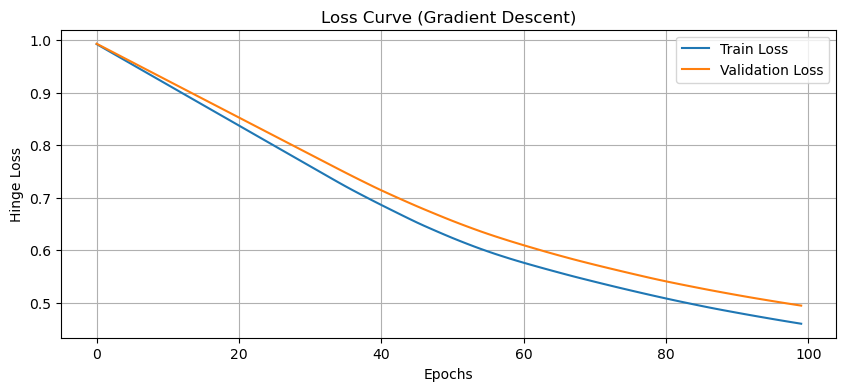

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(loss_gd_train, label='Train Loss')
plt.plot(loss_gd_val, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Hinge Loss')
plt.title('Loss Curve (Gradient Descent)')
plt.legend()
plt.grid(True)
plt.show()

1-GD Train Loss (Blue line):
It steadily decreases, showing that the SVM model using Gradient Descent (GD) is learning effectively and reducing error smoothly.

2-GD Validation Loss (Orange line):
Also decreasing, though a bit noisier than training loss — which is expected because validation data naturally varies more.


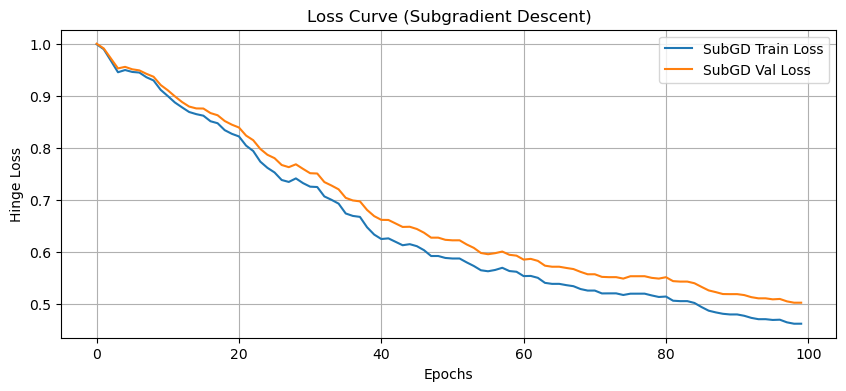

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(loss_sg_train, label='SubGD Train Loss')
plt.plot(loss_sg_val, label='SubGD Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Hinge Loss')
plt.title('Loss Curve (Subgradient Descent)')
plt.legend()
plt.grid(True)
plt.show()

🔍**SubGD Train Loss (blue) & SubGD Validation Loss (orange):**

These represent Stochastic Gradient Descent (SubGD), which updates the model based on single samples. That’s why these lines are more jagged or "noisy."
Still, both show a general downward trend, which is good — the model is learning.


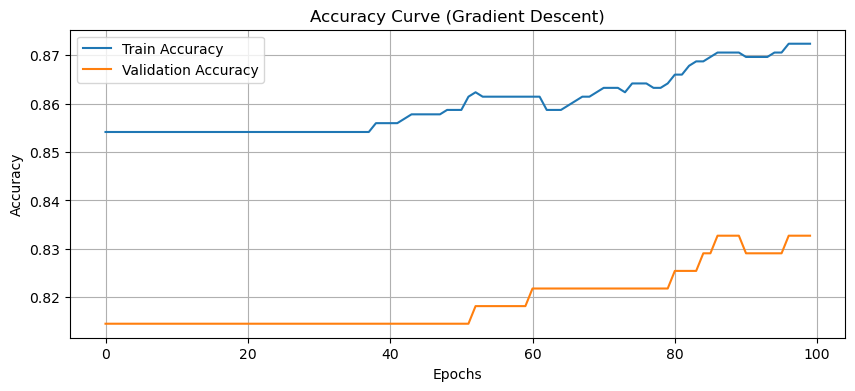

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(acc_gd_train, label='Train Accuracy')
plt.plot(acc_gd_val, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve (Gradient Descent)')
plt.legend()
plt.grid(True)
plt.show()

1-GD Train Accuracy (Blue line):
Stays around 0.85 or higher — the model is consistently performing well on training data.

2-GD Validation Accuracy (Orange line):
Slightly lower than training accuracy — indicating some possible overfitting, but still stable.


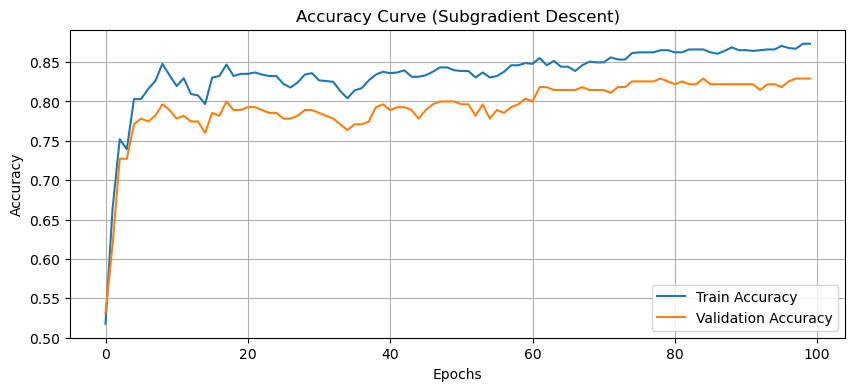

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(acc_sg_train, label='Train Accuracy')
plt.plot(acc_sg_val, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve (Subgradient Descent)')
plt.legend()
plt.grid(True)
plt.show()

1-SubGD Train Accuracy (blue line):
Starts higher and even reaches above 0.85 — showing fast learning on training data using SubGD.

2-SubGD Validation Accuracy (orange line):
Lower than training and highly fluctuating — this could be due to the randomness of SubGD or because it's overfitting quickly to the training data.


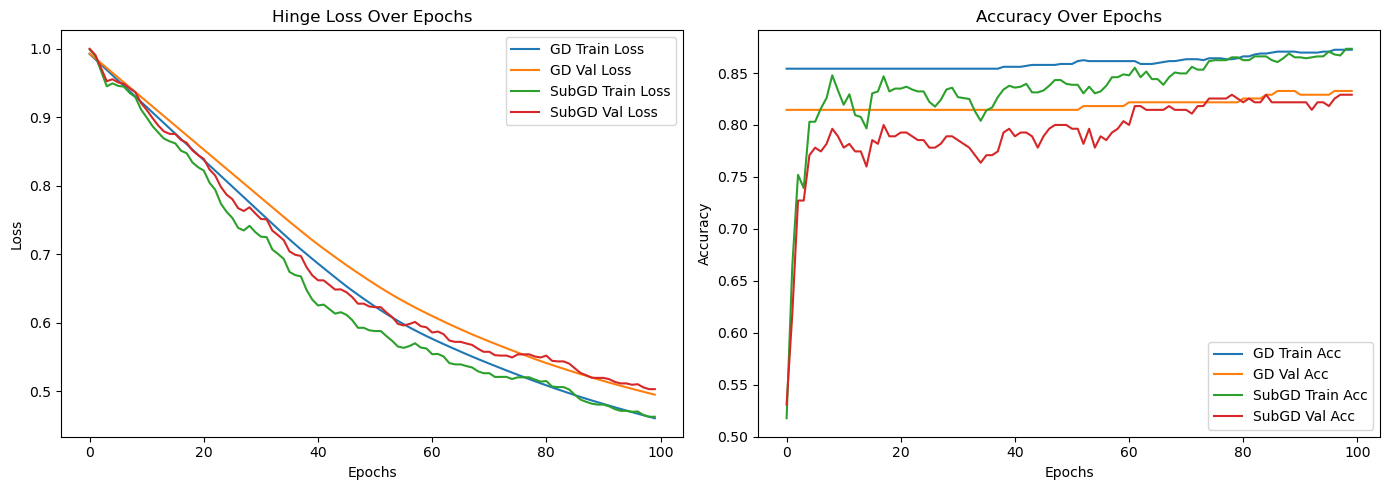

In [17]:

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_gd_train, label='GD Train Loss')
plt.plot(loss_gd_val, label='GD Val Loss')
plt.plot(loss_sg_train, label='SubGD Train Loss')
plt.plot(loss_sg_val, label='SubGD Val Loss')
plt.title("Hinge Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_gd_train, label='GD Train Acc')
plt.plot(acc_gd_val, label='GD Val Acc')
plt.plot(acc_sg_train, label='SubGD Train Acc')
plt.plot(acc_sg_val, label='SubGD Val Acc')
plt.title("Accuracy Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


🔍**Conclusion from this left graph:**
All methods reduce the loss over time. GD is smoother and more stable. SubGD is more volatile, but still effective.

🔍**Conclusion from this right graph:**
GD gives stable and consistent accuracy.
SubGD learns quickly but has more variability and possibly worse generalization.

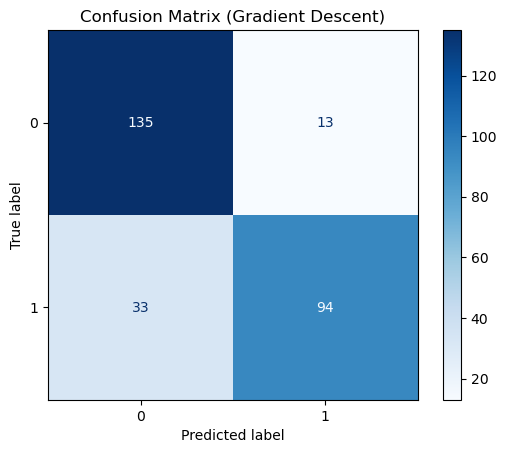

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on validation set
y_pred_val = np.sign(np.dot(X_val, w_gd) + b_gd)

# Convert back from {-1, 1} to {0, 1} if needed
y_val_binary = np.where(y_val == -1, 0, 1)
y_pred_binary = np.where(y_pred_val == -1, 0, 1)

cm = confusion_matrix(y_val_binary, y_pred_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix (Gradient Descent)")
plt.show()

🔍**Interpretation:**

True Negatives (TN) = 135: Model correctly predicted class 0.

False Positives (FP) = 13: Model incorrectly predicted 1 when it was actually 0.

False Negatives (FN) = 33: Model incorrectly predicted 0 when it was actually 1.

True Positives (TP) = 94: Model correctly predicted class 1.

🔍**From this confusion matrix, we can conclude:**

The model does a good job at predicting class 0 (most true 0s are correctly identified).

The model is fairly strong at predicting class 1 but makes more mistakes compared to class 0.

🚀**Errors:**

13 instances where class 0 was wrongly classified as 1 (false positive).

33 instances where class 1 was wrongly classified as 0 (false negative).

The model has better precision and recall for class 0 compared to class 1.



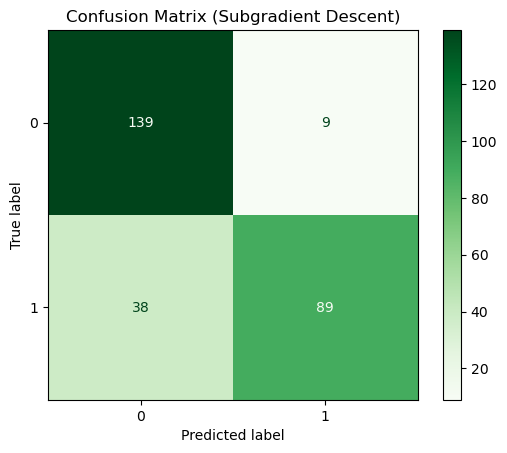

In [19]:
# Predict on validation set using SubGD
y_pred_val_subgd = np.sign(np.dot(X_val, w_sg) + b_sg)

# Convert {-1, 1} to {0, 1} for confusion matrix
y_val_binary = np.where(y_val == -1, 0, 1)
y_pred_binary_subgd = np.where(y_pred_val_subgd == -1, 0, 1)

# Compute and display the confusion matrix
cm_subgd = confusion_matrix(y_val_binary, y_pred_binary_subgd)
disp_subgd = ConfusionMatrixDisplay(confusion_matrix=cm_subgd)
disp_subgd.plot(cmap='Greens')
plt.title("Confusion Matrix (Subgradient Descent)")
plt.show()

🔍**Interpretation:**

True Negatives (TN) = 139: Model correctly predicted class 0.

False Positives (FP) = 9: Model incorrectly predicted 1 when it was actually 0.

False Negatives (FN) = 38: Model incorrectly predicted 0 when it was actually 1.

True Positives (TP) = 89: Model correctly predicted class 1.

🔍**From this confusion matrix, we can conclude:**

The model does a good job at predicting class 0 (most true 0s are correctly identified).

The model is fairly strong at predicting class 1 but makes more mistakes compared to class 0.

🚀**Errors:**

9 instances where class 0 was wrongly classified as 1 (false positive).

38 instances where class 1 was wrongly classified as 0 (false negative).

The model has better precision and recall for class 0 compared to class 1.



🔥**Comparison & Conclusion:**

Subgradient Descent is slightly better at detecting class 0 (real 0s) — fewer false positives (9 vs 13).

Gradient Descent is better at detecting class 1 — fewer false negatives (33 vs 38) and higher true positives (94 vs 89).

If class 1 is more important (e.g., detecting feak banknotes), Gradient Descent would be the better choice.

If class 0 is more important (e.g., correctly identifying real banknotes), Subgradient Descent performs slightly better.